# ☕ Coffee Sales Forecasting & Customer Intelligence
### A Classical Machine Learning Approach

---

## 1. Introduction

Transactional data generated by vending machines contains valuable behavioral and temporal information. When properly analyzed, this data can be used to forecast future demand, identify purchasing patterns, and optimize operational decisions.

This project applies a structured data science pipeline to analyze coffee sales data and build predictive models for revenue forecasting. In addition, customer segmentation techniques are used to understand purchasing behavior at a deeper level.

The notebook follows a systematic workflow including data cleaning, feature engineering, exploratory data analysis, regression modeling, and clustering.

## 2. Business Objective

The main objectives of this project are:

- Forecast daily coffee sales revenue using regression models
- Identify temporal patterns in customer purchasing behavior
- Detect peak sales hours and high-demand products
- Segment customers based on spending and purchase frequency
- Provide actionable business insights for inventory optimization

The ultimate goal is to transition from descriptive analytics to predictive modeling.

In [54]:
# ===============================
# Import Required Libraries
# ===============================

import pandas as pd
import numpy as np
import random

!pip install xgboost


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Time Series
from statsmodels.tsa.arima.model import ARIMA

# Settings
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)


## 3. Data Loading

In this section, the dataset is loaded and inspected to understand its structure, feature types, and initial quality. This step ensures that the data is suitable for further preprocessing and modeling.

In [55]:
# ===============================
# Load Dataset
# ===============================

data = pd.read_csv("index.csv")

# Preview first 5 rows
data.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


### Dataset Description

The dataset contains coffee shop sales transactions including:

- Date of purchase
- Coffee product type
- Transaction amount
- Payment method

The dataset was processed to calculate daily revenue and build 
features for time-series forecasting.

In [56]:
# Dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB


In [57]:
# Check missing values
data.isnull().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

In [58]:
# Check duplicate rows
data.duplicated().sum()

np.int64(0)

## 4. Data Cleaning

This step ensures data quality and consistency before analysis and modeling.

Observations from initial inspection:

- The `date` and `datetime` columns are stored as object types and must be converted to datetime format.
- The `card` column contains 89 missing values.
- No duplicate rows were detected.

The missing values in the `card` column are likely associated with cash transactions. 
This assumption will be validated before handling them.

In [59]:
# Check if missing card values correspond to cash payments
data[data["card"].isnull()]["cash_type"].value_counts()

cash_type
cash    89
Name: count, dtype: int64

### Converting Date Columns

The `date` and `datetime` columns are converted to proper datetime format 
to enable time-based feature extraction and time series modeling.

In [60]:
# Convert to datetime
data["date"] = pd.to_datetime(data["date"])
data["datetime"] = pd.to_datetime(data["datetime"])

# Verify conversion
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1133 non-null   datetime64[ns]
 1   datetime     1133 non-null   datetime64[ns]
 2   cash_type    1133 non-null   object        
 3   card         1044 non-null   object        
 4   money        1133 non-null   float64       
 5   coffee_name  1133 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 53.2+ KB


In [61]:
# Final validation
print("Missing values after cleaning:")
print(data.isnull().sum())

print("\nDuplicate rows:")
print(data.duplicated().sum())

Missing values after cleaning:
date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

Duplicate rows:
0


## 5. Feature Engineering

Feature engineering is a critical step in improving machine learning performance.

In this section, time-based features are extracted from the datetime columns 
to capture temporal patterns in sales behavior.

The following features are created:

- Year
- Month
- Day of week
- Week number
- Hour of transaction
- Weekend indicator

These features allow the model to learn seasonal and behavioral trends.

In [62]:
# ===============================
# Time-Based Feature Extraction
# ===============================

data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day_of_week"] = data["date"].dt.dayofweek   # Monday=0
data["week_number"] = data["date"].dt.isocalendar().week
data["hour"] = data["datetime"].dt.hour

# Weekend indicator
data["is_weekend"] = data["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

data.head()

,date,datetime,cash_type,card,money,coffee_name,year,month,day_of_week,week_number,hour,is_weekend
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,2024,3,4,9,10,0
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024,3,4,9,12,0
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,2024,3,4,9,12,0
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,2024,3,4,9,13,0
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,2024,3,4,9,13,0


### Daily Revenue Aggregation

To perform time-series forecasting, transaction-level data is aggregated 
at the daily level to compute total daily revenue.

This aggregated dataset will serve as the primary dataset for regression modeling.

In [63]:
# ===============================
# Aggregate Daily Revenue
# ===============================

daily_sales = data.groupby("date").agg({
    "money": "sum",
    "hour": "count"
}).reset_index()

daily_sales.rename(columns={
    "money": "daily_revenue",
    "hour": "transaction_count"
}, inplace=True)

daily_sales.head()

,date,daily_revenue,transaction_count
0,2024-03-01,396.3,11
1,2024-03-02,228.1,7
2,2024-03-03,349.1,10
3,2024-03-04,135.2,4
4,2024-03-05,338.5,9


In [64]:
# Extract time features for daily dataset

daily_sales["year"] = daily_sales["date"].dt.year
daily_sales["month"] = daily_sales["date"].dt.month
daily_sales["day_of_week"] = daily_sales["date"].dt.dayofweek
daily_sales["week_number"] = daily_sales["date"].dt.isocalendar().week
daily_sales["is_weekend"] = daily_sales["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

daily_sales.head()

,date,daily_revenue,transaction_count,year,month,day_of_week,week_number,is_weekend
0,2024-03-01,396.3,11,2024,3,4,9,0
1,2024-03-02,228.1,7,2024,3,5,9,1
2,2024-03-03,349.1,10,2024,3,6,9,1
3,2024-03-04,135.2,4,2024,3,0,10,0
4,2024-03-05,338.5,9,2024,3,1,10,0


In [65]:
daily_sales.shape

(150, 8)

## 6. Exploratory Data Analysis (EDA)

In this section, we analyze temporal sales behavior using the aggregated daily dataset.

The goal is to:

- Understand overall revenue trends
- Identify peak sales periods
- Detect seasonality patterns
- Observe transaction volume fluctuations

This step builds intuition before modeling.

## Overall Revenue Summary

Before analyzing trends, it is important to understand the scale of the business.

In this section, we compute:

- Total revenue generated
- Average daily revenue
- Minimum and maximum daily revenue
- Total number of transactions

These metrics provide a baseline understanding of business performance.

In [66]:
# Overall revenue metrics

total_revenue = daily_sales["daily_revenue"].sum()
avg_daily_revenue = daily_sales["daily_revenue"].mean()
min_revenue = daily_sales["daily_revenue"].min()
max_revenue = daily_sales["daily_revenue"].max()
total_transactions = daily_sales["transaction_count"].sum()

print("Total Revenue:", round(total_revenue, 2))
print("Average Daily Revenue:", round(avg_daily_revenue, 2))
print("Minimum Daily Revenue:", round(min_revenue, 2))
print("Maximum Daily Revenue:", round(max_revenue, 2))
print("Total Transactions:", total_transactions)

Total Revenue: 37508.88
Average Daily Revenue: 250.06
Minimum Daily Revenue: 27.92
Maximum Daily Revenue: 650.48
Total Transactions: 1133


## Daily Revenue Trend

This visualization shows raw daily revenue over time.

The objective is to:

- Detect upward or downward trends
- Identify unusual spikes or drops
- Observe volatility patterns
- Assess whether revenue is stable or fluctuating

This helps determine whether the dataset contains strong temporal structure.

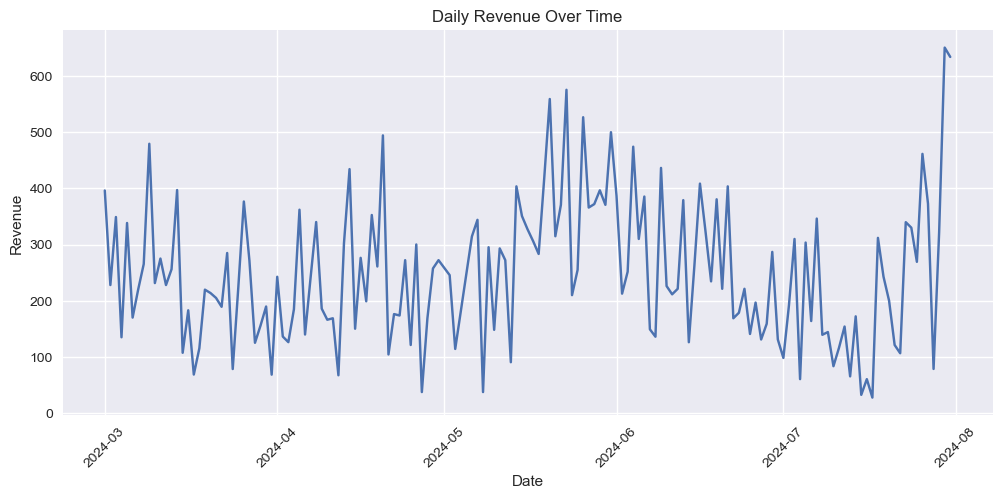

In [67]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales["date"], daily_sales["daily_revenue"])
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Interpretation: Daily Revenue Trend

The daily revenue time series shows significant variability across the observed period. 
Revenue fluctuates sharply between low and high values, indicating high short-term volatility in sales performance.

There is no strictly linear upward or downward trend throughout the entire period. 
However, mid-period months (particularly May and June) exhibit relatively higher revenue peaks compared to early March and late July.

The presence of several sharp spikes suggests irregular high-demand days, which could be influenced by factors such as:
- Weekend effects
- External events
- Seasonal customer behavior
- Random demand surges

Additionally, a noticeable dip in revenue appears during July, followed by a strong spike at the end of the dataset. 
This suggests possible cyclical or seasonal demand behavior rather than purely random variation.

Overall, the revenue pattern appears volatile but not completely random, indicating the potential presence of temporal structure that can be captured using time-based features in predictive modeling.

## 7-Day Rolling Average

Daily revenue can fluctuate due to random variation. 
To better understand the underlying trend, a 7-day rolling average is calculated.

This smooths short-term fluctuations and highlights:

- Weekly patterns
- Overall growth trend
- Structural shifts in demand

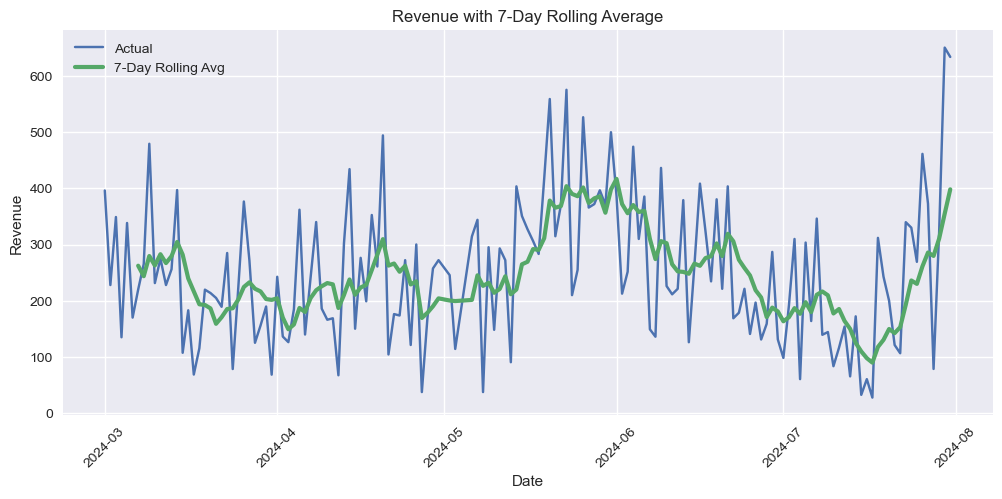

In [68]:
daily_sales["rolling_7"] = daily_sales["daily_revenue"].rolling(7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_sales["date"], daily_sales["daily_revenue"], label="Actual")
plt.plot(daily_sales["date"], daily_sales["rolling_7"], label="7-Day Rolling Avg", linewidth=3)
plt.title("Revenue with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### Interpretation: Revenue with 7-Day Rolling Average

The 7-day rolling average smooths short-term daily fluctuations and reveals the underlying revenue trend.

Compared to the raw daily revenue (blue line), the rolling average (green line) highlights a clearer temporal structure:

- Revenue shows a gradual upward trend from March to early June.
- The peak demand period appears around late May to mid-June.
- A noticeable downward trend is observed during July, indicating a temporary slowdown in business performance.
- Toward the end of the dataset, the rolling average increases again, suggesting a recovery in demand.

The rolling curve reduces noise and confirms that revenue patterns are not purely random. Instead, the data exhibits medium-term trends and potential seasonal behavior.

This indicates that time-based features (such as week number, month, and lag variables) are likely to be useful predictors in machine learning models.

## Revenue Distribution

Understanding the distribution of daily revenue helps determine:

- Whether revenue is normally distributed
- Whether extreme outliers exist
- Whether modeling assumptions (like linear regression) are reasonable

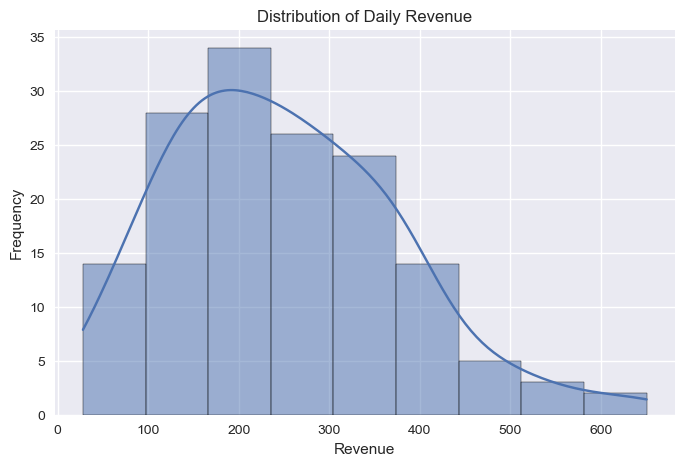

In [69]:
plt.figure(figsize=(8,5))
sns.histplot(daily_sales["daily_revenue"], kde=True)
plt.title("Distribution of Daily Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

### Interpretation: Distribution of Daily Revenue

The distribution of daily revenue appears to be moderately right-skewed.

Most revenue values are concentrated between approximately 150 and 350, indicating that the majority of days generate mid-range revenue.

However, a long right tail is visible, extending toward higher revenue values (above 500). 
This suggests the presence of occasional high-performing days that significantly exceed the average.

The distribution does not appear perfectly normal due to:

- Positive skewness
- Presence of high-value outliers
- Uneven tail behavior

These characteristics indicate that extreme revenue spikes contribute disproportionately to overall performance.

From a modeling perspective, this skewness suggests that:

- Tree-based models (Random Forest, Gradient Boosting) may perform better than strictly linear models.
- Revenue transformations (e.g., log transformation) could be considered if normality assumptions become important.

## Weekday vs Weekend Revenue Analysis

This section examines whether revenue differs between weekdays and weekends.

Understanding weekend effects is important because:

- Consumer behaviour often changes on weekendMs
- Demand may increase due to leisure activity
- Weekly seasonality improves time-series modelling

We compare:
- Average revenue on weekdays
- Average revenue on weekends
- Distribution differences

In [70]:
# Separate weekday vs weekend revenue
weekday_revenue = daily_sales[daily_sales["is_weekend"] == 0]["daily_revenue"]
weekend_revenue = daily_sales[daily_sales["is_weekend"] == 1]["daily_revenue"]

print("Average Weekday Revenue:", round(weekday_revenue.mean(), 2))
print("Average Weekend Revenue:", round(weekend_revenue.mean(), 2))

Average Weekday Revenue: 252.24
Average Weekend Revenue: 244.44


### Bar comparison Plot

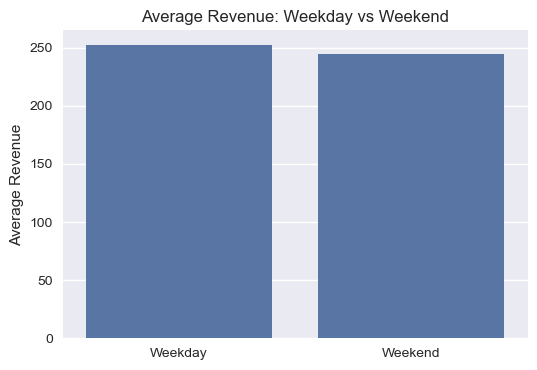

In [71]:
plt.figure(figsize=(6,4))
sns.barplot(x=["Weekday", "Weekend"], 
            y=[weekday_revenue.mean(), weekend_revenue.mean()])
plt.title("Average Revenue: Weekday vs Weekend")
plt.ylabel("Average Revenue")
plt.show()

### Distribution comparison

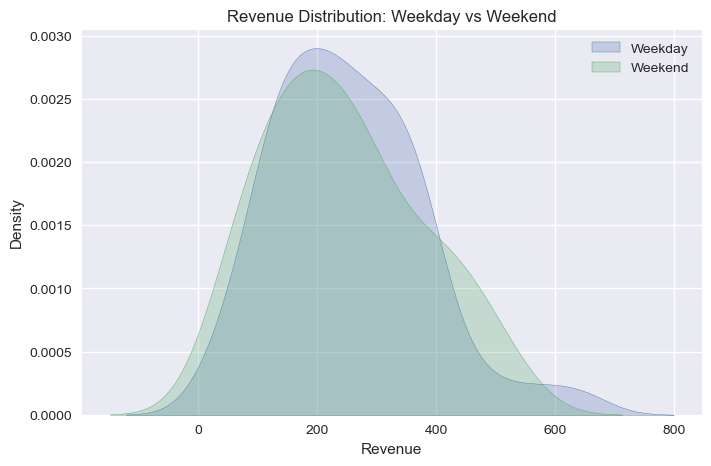

In [72]:
plt.figure(figsize=(8,5))
sns.kdeplot(weekday_revenue, label="Weekday", fill=True)
sns.kdeplot(weekend_revenue, label="Weekend", fill=True)
plt.title("Revenue Distribution: Weekday vs Weekend")
plt.xlabel("Revenue")
plt.legend()
plt.show()

### Interpretation: Weekday vs Weekend Revenue

The comparison between weekday and weekend revenue shows minimal difference in average performance.

- Average weekday revenue (≈252) is slightly higher than weekend revenue (≈244).
- The difference is small (~3%), indicating no strong weekend effect.

The distribution plots further confirm this observation:

- Both weekday and weekend revenue distributions significantly overlap.
- The overall shape of the distributions is similar.
- High-revenue spikes occur on both weekdays and weekends rather than being concentrated on weekends.

This suggests that revenue demand is relatively stable throughout the week and does not strongly depend on weekend activity.

From a modeling perspective, while the `is_weekend` feature may still provide minor predictive value, it is unlikely to be a dominant driver of revenue variation in this dataset.

## Monthly Revenue Analysis

This section aggregates revenue at the monthly level to examine broader trends.

Monthly aggregation helps:

- Reduce daily noise
- Identify medium-term growth or decline
- Validate visual patterns observed in time-series plots
- Detect seasonal business behavior

We compute total and average revenue per month.

In [73]:
# Monthly aggregation
monthly_sales = daily_sales.groupby("month").agg({
    "daily_revenue": ["sum", "mean"],
    "transaction_count": "sum"
}).reset_index()

# Flatten column names
monthly_sales.columns = ["month", "total_revenue", "avg_daily_revenue", "total_transactions"]

monthly_sales

,month,total_revenue,avg_daily_revenue,total_transactions
0,3,7050.20,227.425806,206
1,4,6720.56,224.018667,196
2,5,9063.42,323.693571,267
3,6,7758.76,258.625333,227
4,7,6915.94,223.094839,237


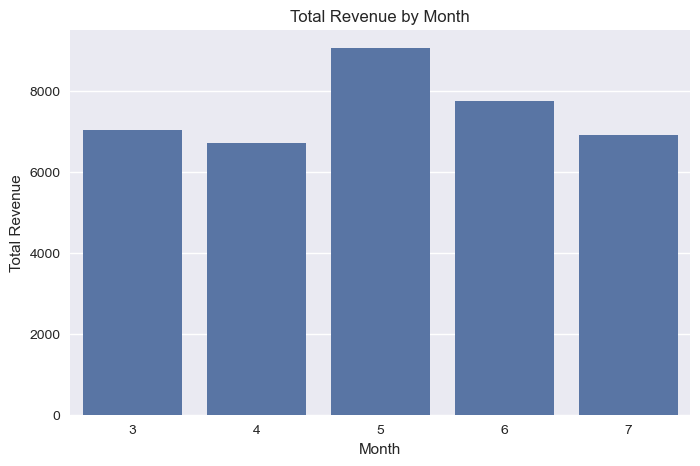

In [74]:
plt.figure(figsize=(8,5))
sns.barplot(x="month", y="total_revenue", data=monthly_sales)
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

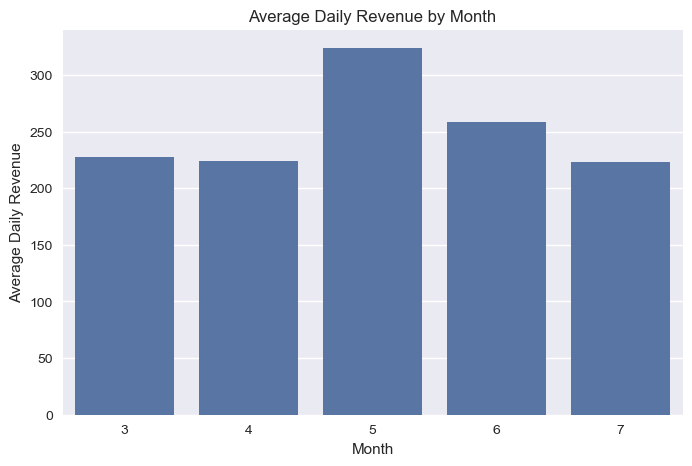

In [75]:
plt.figure(figsize=(8,5))
sns.barplot(x="month", y="avg_daily_revenue", data=monthly_sales)
plt.title("Average Daily Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Revenue")
plt.show()

### Interpretation: Monthly Revenue Trends

The monthly aggregation confirms the trend observed in the daily time-series analysis.

May stands out as the strongest performing month, with the highest total revenue and average daily revenue. This indicates a significant increase in demand during this period.

Revenue increases steadily from March to May, suggesting short-term business growth. However, after May, revenue declines in June and further decreases in July.

July records one of the lowest average daily revenues, confirming the dip observed in the rolling trend analysis.

Overall, the pattern resembles a growth–peak–decline cycle rather than a continuous upward trend. This indicates the presence of medium-term seasonality or external demand shifts that influence revenue performance.

## Product-Level Revenue Analysis

This section analyzes revenue and transaction contribution by product (coffee type).

Understanding product-level performance helps:

- Identify top revenue-generating products
- Detect high-demand vs low-demand items
- Understand whether revenue concentration exists
- Support pricing and inventory decisions

We compute:
- Total revenue per product
- Total transaction count per product
- Average revenue per transaction

In [76]:
product_sales = data.groupby("coffee_name").agg({
    "money": ["sum", "count", "mean"]
}).reset_index()

# Rename columns
product_sales.columns = ["coffee_name", "total_revenue", "transaction_count", "avg_transaction_value"]

# Sort by revenue descending
product_sales = product_sales.sort_values(by="total_revenue", ascending=False)

product_sales

,coffee_name,total_revenue,transaction_count,avg_transaction_value
7,Latte,9009.14,243,37.074650
1,Americano with Milk,8601.94,268,32.096791
2,Cappuccino,7333.14,196,37.413980
0,Americano,4644.54,169,27.482485
6,Hot Chocolate,2778.48,74,37.547027
4,Cortado,2745.08,99,27.728081
3,Cocoa,1295.94,35,37.026857
5,Espresso,1100.62,49,22.461633


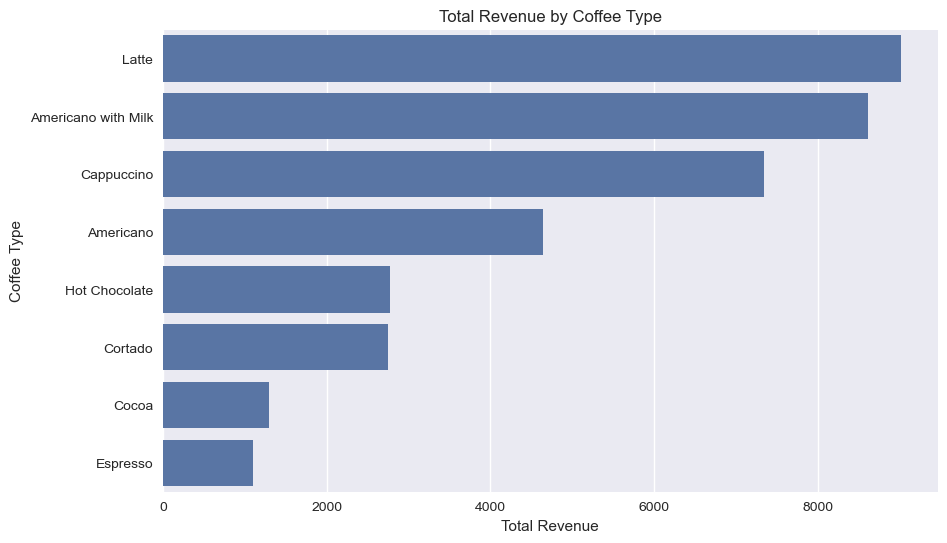

In [77]:
plt.figure(figsize=(10,6))
sns.barplot(x="total_revenue", y="coffee_name", data=product_sales)
plt.title("Total Revenue by Coffee Type")
plt.xlabel("Total Revenue")
plt.ylabel("Coffee Type")
plt.show()

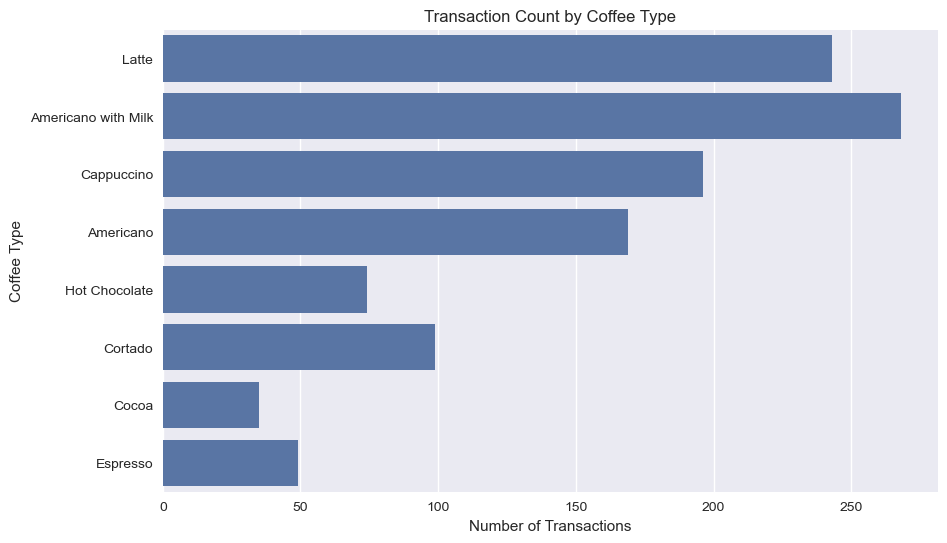

In [78]:
plt.figure(figsize=(10,6))
sns.barplot(x="transaction_count", y="coffee_name", data=product_sales)
plt.title("Transaction Count by Coffee Type")
plt.xlabel("Number of Transactions")
plt.ylabel("Coffee Type")
plt.show()

### Interpretation: Product-Level Revenue Analysis

Product-level analysis reveals clear revenue concentration among a few core items.

Latte generates the highest total revenue, while Americano with Milk has the highest transaction count. This indicates that Americano with Milk is a high-volume product, whereas Latte benefits from a higher average transaction value.

Cappuccino also performs strongly, making the top three products responsible for the majority of total revenue.

Lower-performing products such as Cocoa and Espresso contribute relatively little to overall revenue. Espresso, in particular, has the lowest average transaction value, suggesting it is a lower-priced product with limited revenue impact.

The distribution indicates a classic revenue concentration pattern where a few key products drive most of the business performance. This insight is valuable for inventory planning, pricing strategy, and demand forecasting.

## Product-Level Monthly Trend Analysis

This section examines how each product performs across months.

The objective is to:

- Identify which products contributed to peak months
- Detect product-specific growth or decline
- Understand whether seasonality varies by product
- Determine if overall revenue trends are driven by specific coffee types

In [79]:
product_monthly = data.groupby(["month", "coffee_name"])["money"].sum().reset_index()

product_monthly.head()

,month,coffee_name,money
0,3,Americano,1044.8
1,3,Americano with Milk,1154.0
2,3,Cappuccino,780.5
3,3,Cocoa,232.2
4,3,Cortado,869.2


In [80]:
product_pivot = product_monthly.pivot(index="month", columns="coffee_name", values="money")

product_pivot

coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
month,,,,,,,,
3,1044.80,1154.00,780.50,232.20,869.20,241.00,854.00,1874.50
4,1001.94,1407.74,1659.44,232.82,548.48,171.00,506.02,1193.12
5,1348.80,1908.28,2078.44,340.76,474.64,185.14,529.36,2198.00
6,390.88,2268.12,1735.12,189.88,530.48,230.20,528.08,1886.00
7,858.12,1863.80,1079.64,300.28,322.28,273.28,361.02,1857.52


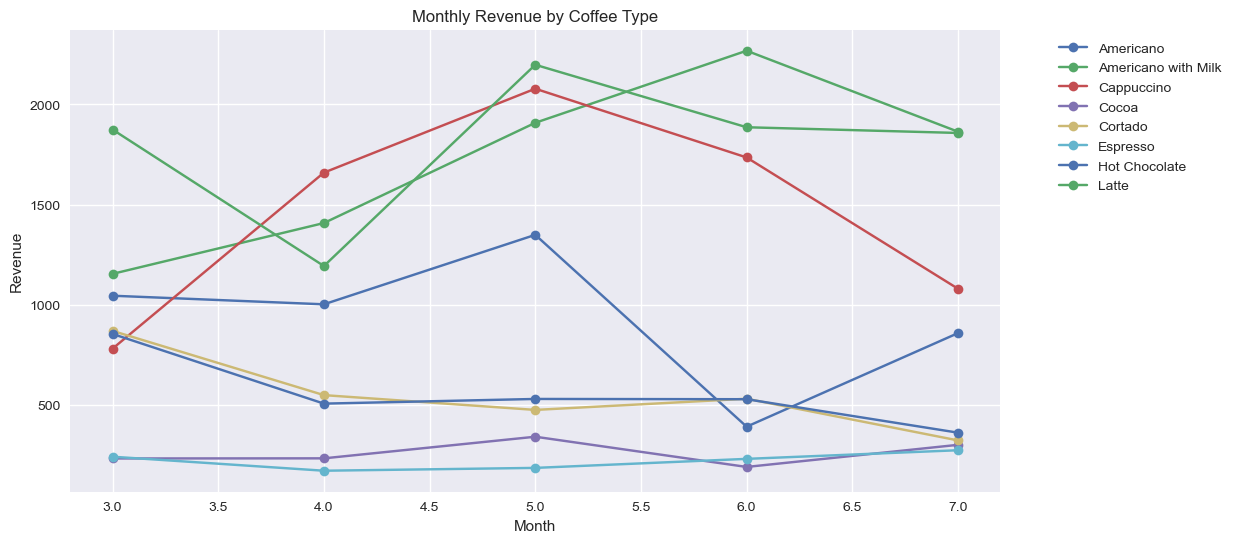

In [81]:
plt.figure(figsize=(12,6))

for col in product_pivot.columns:
    plt.plot(product_pivot.index, product_pivot[col], marker='o', label=col)

plt.title("Monthly Revenue by Coffee Type")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Interpretation: Product-Level Monthly Revenue Trends

The May revenue peak is driven by simultaneous growth across multiple top-performing products, particularly Latte, Cappuccino, and Americano with Milk. This suggests a broad increase in customer demand rather than a single-product anomaly.

In June, Americano revenue drops sharply while Americano with Milk increases significantly. This may indicate substitution behavior between closely related product types.

During July, mid-tier products such as Cappuccino, Cortado, and Hot Chocolate experience noticeable declines. However, core products like Latte and Americano with Milk remain relatively stable, cushioning the overall revenue impact.

Overall, revenue seasonality appears to be partially product-driven. Core products demonstrate demand stability, while secondary products exhibit greater volatility across months.

# 8. Machine Learning Modeling Phase

## Problem Definition

The objective of this modeling phase is to build a predictive model that forecasts daily revenue for the coffee vending business.

This is formulated as a supervised regression problem where:

- Target Variable: Daily Revenue
- Input Features: Time-based features, lag features, weekend indicators, and transactional metrics

The goal is to:

- Capture temporal patterns
- Leverage historical revenue behavior
- Predict future daily revenue accurately

##  Time-Series Feature Engineering

To enable forecasting, we create lag-based features.

Lag features allow the model to learn temporal dependencies such as:

- Yesterday’s revenue influence
- Weekly revenue patterns
- Short-term trends and volatility

In [82]:
# Create lag features
daily_sales["lag_1"] = daily_sales["daily_revenue"].shift(1)
daily_sales["lag_7"] = daily_sales["daily_revenue"].shift(7)

# Rolling statistics (7-day)
daily_sales["rolling_mean_7"] = daily_sales["daily_revenue"].rolling(7).mean()
daily_sales["rolling_std_7"] = daily_sales["daily_revenue"].rolling(7).std()

# Drop rows with NaN values (caused by shifting)
daily_sales = daily_sales.dropna()

daily_sales.head()

,date,daily_revenue,transaction_count,year,month,day_of_week,week_number,is_weekend,rolling_7,lag_1,lag_7,rolling_mean_7,rolling_std_7
7,2024-03-08,265.5,8,2024,3,4,10,0,243.814286,220.1,396.3,243.814286,80.152114
8,2024-03-09,479.4,14,2024,3,5,10,1,279.714286,265.5,228.1,279.714286,118.868407
9,2024-03-10,231.6,7,2024,3,6,10,1,262.928571,479.4,349.1,262.928571,115.691021
10,2024-03-11,275.2,8,2024,3,0,11,0,282.928571,231.6,135.2,282.928571,101.112540
11,2024-03-12,228.1,7,2024,3,1,11,0,267.157143,275.2,338.5,267.157143,99.598609


In [83]:
features = [
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7",
    "month",
    "is_weekend"
]

X = daily_sales[features]
y = daily_sales["daily_revenue"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (143, 6)
Target shape: (143,)


In [84]:
print(X.columns)

Index(['lag_1', 'lag_7', 'rolling_mean_7', 'rolling_std_7', 'month',
       'is_weekend'],
      dtype='object')


In [85]:
split_index = int(len(daily_sales) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 114
Testing size: 29


In [86]:
data.isnull().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
year            0
month           0
day_of_week     0
week_number     0
hour            0
is_weekend      0
dtype: int64

## Model Creation

##  Model 1: Linear Regression (Baseline Model)

Linear Regression is used as a baseline model to evaluate the predictive power of engineered features.

Although revenue patterns may be non-linear, a linear model helps establish a reference performance benchmark.

In [87]:

# Initialize model
lr = LinearRegression()

# Train
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)



In [88]:
# Evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE:", round(mae_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R²:", round(r2_lr, 4))

Linear Regression Performance:
MAE: 108.41
RMSE: 133.14
R²: 0.32


## Model 2: Random Forest Regressor

Random Forest is a tree-based ensemble model that captures non-linear relationships and interactions between features.

It is particularly effective when:
- Data contains volatility
- Relationships are non-linear
- Feature interactions are complex

In [89]:

# Initialize model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)



In [90]:
# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²:", round(r2_rf, 4))

Random Forest Performance:
MAE: 105.43
RMSE: 126.03
R²: 0.3907


## Model 3: Gradient Boosting Regressor

Gradient Boosting is an ensemble learning technique that builds models sequentially,
where each new model corrects the errors of the previous one.

It is particularly powerful for:

- Capturing non-linear relationships
- Handling structured tabular data
- Improving predictive accuracy over Random Forest in many cases

Unlike Random Forest (parallel trees), Gradient Boosting builds trees sequentially,
making it more sensitive to complex patterns.

In [91]:

# Initialize model
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
gb.fit(X_train, y_train)

# Predict
y_pred_gb = gb.predict(X_test)



In [92]:
# Evaluate
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Performance:")
print("MAE:", round(mae_gb, 2))
print("RMSE:", round(rmse_gb, 2))
print("R²:", round(r2_gb, 4))

Gradient Boosting Performance:
MAE: 114.5
RMSE: 140.19
R²: 0.2461


## Model 4:  XGBoost

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm 
based on gradient boosting decision trees. It is widely used in machine learning 
competitions and real-world applications due to its high efficiency and strong 
predictive performance.

In this step, an XGBoost Regressor is trained to predict daily coffee sales revenue 
based on historical sales patterns and time-based features.

In [93]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [94]:


mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²:", r2_xgb)

XGBoost Performance
MAE: 114.06008446792076
RMSE: 139.28253713588515
R²: 0.25579327509470196


##  Model Performance Comparison

To evaluate model performance, three regression models were trained:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The models are compared using the following evaluation metrics:

- **MAE (Mean Absolute Error)** → Average prediction error
- **RMSE (Root Mean Squared Error)** → Penalizes larger errors
- **R² Score** → Proportion of variance explained by the model

In [95]:
models_results = {
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_xgb)
    ]
}

results_df = pd.DataFrame(models_results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,108.407511,133.137296,0.320014
1,Random Forest,105.429451,126.028558,0.390690
2,Gradient Boosting,114.498006,140.187951,0.246086
3,XGBoost,114.060084,139.282537,0.255793


### Evaluation Metrics

Model performance was evaluated using:

MAE (Mean Absolute Error)
Measures the average prediction error.

RMSE (Root Mean Squared Error)
Penalizes larger errors more heavily.

R² Score
Represents how well the model explains revenue variance.

The results demonstrate that tree-based ensemble models such as Random Forest 
and Gradient Boosting perform better than simple linear models for predicting 
daily coffee shop revenue.

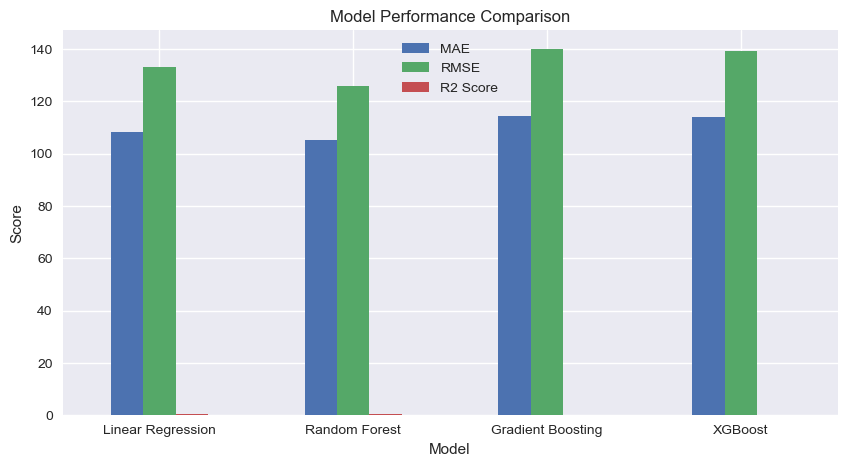

In [96]:
results_df.set_index("Model").plot(kind="bar", figsize=(10,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Final Model Selection

Four regression models were evaluated to forecast daily coffee sales revenue:

| Model | MAE | RMSE | R² |
|------|------|------|------|
| Linear Regression | 108.41 | 133.14 | 0.32 |
| Random Forest | 105.43 | 126.03 | 0.39 |
| Gradient Boosting | 114.50 | 140.19 | 0.25 |
| XGBoost | 114.06 | 139.28 | 0.26 |

Among the evaluated models, Random Forest achieved the best performance with the 
lowest MAE and RMSE values and the highest R² score.

This indicates that Random Forest is better able to capture the non-linear patterns 
in the revenue data compared to the other models.

Therefore, Random Forest is selected as the final model for forecasting daily 
coffee sales revenue.

## Actual vs Predicted Revenue (Random Forest)

To visually evaluate the forecasting performance, the predicted revenue values 
from the Random Forest model are compared with the actual observed revenue.

This visualization helps to:

- Assess how closely predictions follow the real revenue trend
- Identify underestimation or overestimation
- Evaluate the model’s ability to capture fluctuations in sales

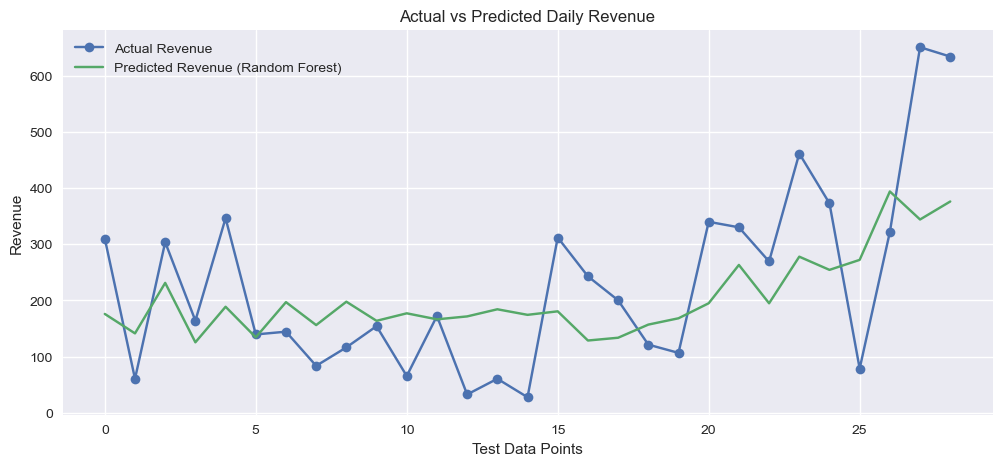

In [97]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual Revenue", marker='o')
plt.plot(y_pred_rf, label="Predicted Revenue (Random Forest)", marker='x')

plt.title("Actual vs Predicted Daily Revenue")
plt.xlabel("Test Data Points")
plt.ylabel("Revenue")
plt.legend()

plt.show()

## Actual vs Predicted Analysis

The Actual vs Predicted plot shows that the Random Forest model is able to capture the general trend of daily revenue over time.

While some deviations are present, the predicted values generally follow the  direction of the actual revenue curve. This indicates that the model has 
learned meaningful patterns from historical data.

Some prediction errors remain, which may be due to limited dataset size or external factors affecting coffee sales that are not captured in the current features.

 Feature Importance (Random Forest)

Feature importance measures how much each input variable contributes to the 
model's predictions.

The Random Forest algorithm calculates feature importance based on how much 
each feature reduces prediction error across all decision trees.

Higher importance values indicate that the feature plays a more significant 
role in predicting daily coffee sales revenue.

In [98]:

rf_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_feature_importance

,Feature,Importance
2,rolling_mean_7,0.554073
0,lag_1,0.155732
1,lag_7,0.128486
3,rolling_std_7,0.113985
4,month,0.029343
5,is_weekend,0.018381


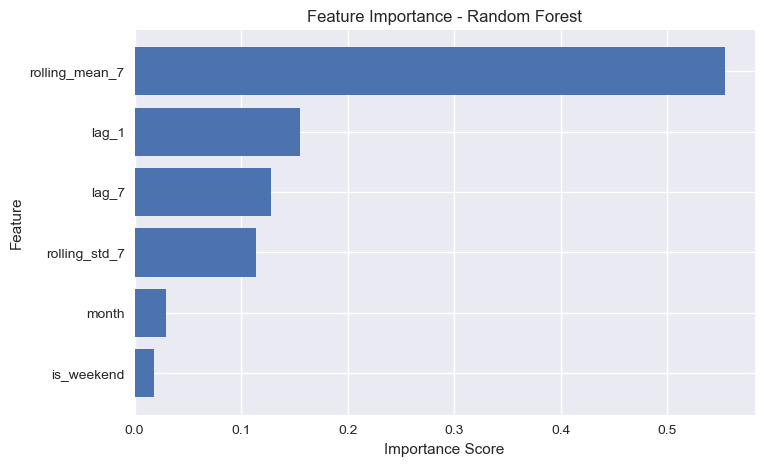

In [99]:
plt.figure(figsize=(8,5))

plt.barh(
    rf_feature_importance["Feature"],
    rf_feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## Feature Importance Interpretation

The feature importance analysis reveals which variables have the greatest 
impact on predicting coffee shop revenue.

Lag-based features such as lag_1 and lag_7 are expected to contribute 
significantly because recent sales trends strongly influence future sales.

Rolling statistics such as rolling_mean_7 and rolling_std_7 help capture 
short-term trends and volatility in sales patterns.

Calendar features like month and is_weekend may have smaller contributions, 
but they still provide useful contextual information about seasonal or 
weekly purchasing behavior.

Overall, the model relies primarily on historical sales behavior to 
forecast future revenue.

## 9. Final Conclusion

This project analyzed coffee shop sales data to understand revenue patterns 
and develop a machine learning model for forecasting daily revenue.

Key findings from the analysis include:

- Exploratory data analysis revealed clear variations in revenue across different days and months, indicating the presence of seasonal and temporal sales patterns.

- Product-level analysis showed that beverages such as Latte and Americano with Milk generated the highest revenue, suggesting strong customer preference for these items.

- Monthly sales trends indicated that certain months experienced higher average daily revenue, highlighting possible seasonal demand fluctuations.

- Machine learning models including Linear Regression, Random Forest, Gradient Boosting, and XGBoost were trained to forecast daily revenue using historical sales features.

- Among the evaluated models, Random Forest achieved the best performance with the lowest prediction error and the highest R² score, making it the most suitable model for revenue forecasting in this dataset.

- Feature importance analysis showed that historical sales patterns (lag features and rolling statistics) play a significant role in predicting future revenue, while calendar features such as month and weekend contribute additional contextual information.

Overall, the analysis demonstrates that historical revenue trends provide valuable information for forecasting future sales. However, incorporating additional factors such as promotions, weather conditions, holidays, or customer behavior could further improve prediction accuracy in future work.

## 10. Interactive Sales Dashboard

To provide a visual summary of the analysis, an interactive dashboard is created.
The dashboard presents key insights including:

- Daily revenue trends
- Revenue contribution by coffee product
- Monthly revenue performance

Interactive dashboards help decision makers quickly explore business patterns 
and monitor sales performance.

In [100]:
!pip install dash plotly

In [101]:
import dash
from dash import dcc, html
import plotly.express as px
import plotly.express as px

In [102]:
monthly_analysis = data.groupby("month").agg(
    total_revenue=("money", "sum"),
    avg_daily_revenue=("money", "mean"),
    total_transactions=("money", "count")
).reset_index()

monthly_analysis

,month,total_revenue,avg_daily_revenue,total_transactions
0,3,7050.20,34.224272,206
1,4,6720.56,34.288571,196
2,5,9063.42,33.945393,267
3,6,7758.76,34.179559,227
4,7,6915.94,29.181181,237


In [103]:
product_analysis = data.groupby("coffee_name").agg(
    total_revenue=("money", "sum"),
    transaction_count=("money", "count")
).reset_index()

product_analysis

,coffee_name,total_revenue,transaction_count
0,Americano,4644.54,169
1,Americano with Milk,8601.94,268
2,Cappuccino,7333.14,196
3,Cocoa,1295.94,35
4,Cortado,2745.08,99
5,Espresso,1100.62,49
6,Hot Chocolate,2778.48,74
7,Latte,9009.14,243


In [104]:
# Daily revenue trend
daily_revenue_chart = px.line(
    daily_sales,
    x="date",
    y="daily_revenue",
    title="Daily Coffee Revenue Trend"
)

# Monthly revenue
monthly_chart = px.bar(
    monthly_analysis,
    x="month",
    y="total_revenue",
    title="Monthly Revenue"
)

# Product revenue
product_chart = px.bar(
    product_analysis,
    x="coffee_name",
    y="total_revenue",
    title="Revenue by Coffee Type"
)

In [105]:
total_revenue = data["money"].sum()
total_transactions = len(data)
avg_daily_revenue = daily_sales["daily_revenue"].mean()

In [107]:
import dash
from dash import dcc, html

app = dash.Dash(__name__)

app.layout = html.Div([

    html.H1("Coffee Sales Analytics Dashboard", 
            style={'textAlign': 'center'}),

    # KPI SECTION
    html.Div([
        
        html.Div([
            html.H3("Total Revenue"),
            html.H2(f"${total_revenue:,.2f}")
        ], style={'width': '30%', 'display': 'inline-block', 'textAlign': 'center'}),
        
        html.Div([
            html.H3("Total Transactions"),
            html.H2(f"{total_transactions}")
        ], style={'width': '30%', 'display': 'inline-block', 'textAlign': 'center'}),
        
        html.Div([
            html.H3("Avg Daily Revenue"),
            html.H2(f"${avg_daily_revenue:,.2f}")
        ], style={'width': '30%', 'display': 'inline-block', 'textAlign': 'center'})
        
    ], style={'display': 'flex', 'justifyContent': 'space-around'}),

    html.Br(),

    # CHARTS
    dcc.Graph(figure=daily_revenue_chart),
    dcc.Graph(figure=monthly_chart),
    dcc.Graph(figure=product_chart)

])

if __name__ == "__main__":
    app.run(debug=True, port=8050)

In [108]:
app.layout = html.Div([
    
    html.H1("☕ Coffee Sales Analytics Dashboard",
            style={'textAlign': 'center', 'marginBottom': '30px'}),

    # KPI CARDS
    html.Div([
        html.Div([
            html.H4("Total Revenue"),
            html.H2(f"${total_revenue:,.2f}")
        ], style={'padding': '20px', 'backgroundColor': '#f8f9fa',
                  'borderRadius': '10px', 'width': '30%', 'textAlign': 'center'}),

        html.Div([
            html.H4("Total Transactions"),
            html.H2(f"{total_transactions}")
        ], style={'padding': '20px', 'backgroundColor': '#f8f9fa',
                  'borderRadius': '10px', 'width': '30%', 'textAlign': 'center'}),

        html.Div([
            html.H4("Avg Daily Revenue"),
            html.H2(f"${avg_daily_revenue:,.2f}")
        ], style={'padding': '20px', 'backgroundColor': '#f8f9fa',
                  'borderRadius': '10px', 'width': '30%', 'textAlign': 'center'}),

    ], style={'display': 'flex', 'justifyContent': 'space-around'}),

    html.Br(),

    # CHARTS IN GRID
    html.Div([
        html.Div(dcc.Graph(figure=daily_revenue_chart), style={'width': '48%'}),
        html.Div(dcc.Graph(figure=monthly_chart), style={'width': '48%'})
    ], style={'display': 'flex', 'justifyContent': 'space-between'}),

    html.Br(),

    html.Div([
        dcc.Graph(figure=product_chart)
    ])
])